# Predictive Monitoring - Road Fines Management

**Content**

1. [Data Exploration and Preparation](#Data-Exploration-and-Preparation)
2. [Event Log Enrichment](#Event-Log-Enrichment)
3. [Prefix Extraction](#Prefix-Extraction)
   - [Train/Test Split](#Train/Test-Split)
   - [Prefix Extraction with Fixed Prefix Length](#Prefix-Extraction-with-Fixed-Prefix-Length)
   - [Prefix Extraction with Time Cutoff](#Prefix-Extraction-with-Time-Cutoff)
   - [Determine Prefix Extraction Variant To Analyze](#Determine-Prefix-Extraction-Variant-To-Analyze)
   - [Temporal Aware Global Features](#Temporal-Aware-Global-Features)
   - [Prefix Extraction using Fixed Day Length](#Prefix-Extraction-using-Fixed-Day-Length)
   - [Bucketing](#Bucketing)
4. [Feature Encoding](#Feature-Encoding)
5. [Model Building and Training](#Model-Building-and-Training)
6. [Evaluation](#Evaluation)
   - [Ablation Study](#Ablation-Study)
   - [Prediction Quality](#Prediction-Quality)
   - [Single Feature Ablation Study](#Single-Feature-Ablation-Study)
7. [Interpretation](#Interpretation)

In [67]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
import importlib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from utils import enrichment, feature_engineering, prefix_extraction
from utils import utils as utils_mod

for m in (enrichment, feature_engineering, prefix_extraction, utils_mod):
    importlib.reload(m)

from utils.enrichment import *
from utils.feature_engineering import *
from utils.prefix_extraction import *
from utils.utils import *

## Data Exploration and Preparation

Goals: 
- Learn about the event log in terms of features that we can use for the prediction task
- prepare the data in a way that it does not bias the prediction

In [68]:
event_log = pm4py.read_xes(str(PROJECT_ROOT / "data" / "Road_Traffic_Fine_Management_Process.xes"))
event_log['time:timestamp'] = event_log['time:timestamp'].dt.tz_convert('Europe/Rome')
event_log["case:concept:name"] = event_log["case:concept:name"].astype(str)

parsing log, completed traces ::   0%|          | 0/150370 [00:00<?, ?it/s]

### Event Log Enrichment

In [69]:
# Define main column names
case_id_col = "case:concept:name"
activity_col = "concept:name"
timestamp_col = "time:timestamp"

In [70]:
event_log = event_add_relative_case_time(event_log)
event_log = event_add_relative_log_time(event_log)
event_log = add_inter_event_time(event_log)

In [71]:
display(event_log)

,amount,org:resource,dismissal,concept:name,vehicleClass,totalPaymentAmount,lifecycle:transition,time:timestamp,article,points,case:concept:name,expense,notificationType,lastSent,paymentAmount,matricola,relative_case_time,relative_log_time,time_since_prev
0,35.0,561,NIL,Create Fine,A,0.0,complete,2006-07-24 02:00:00+02:00,157.0,0.0,A1,NaN,NaN,NaN,NaN,NaN,0,2396,0.0
1,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2006-12-05 01:00:00+01:00,NaN,NaN,A1,11.00,NaN,NaN,NaN,NaN,134,2530,134.0
2,35.0,561,NIL,Create Fine,A,0.0,complete,2006-08-02 02:00:00+02:00,157.0,0.0,A100,NaN,NaN,NaN,NaN,NaN,0,2405,0.0
3,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2006-12-12 01:00:00+01:00,NaN,NaN,A100,11.00,NaN,NaN,NaN,NaN,132,2537,132.0
4,NaN,NaN,NaN,Insert Fine Notification,NaN,NaN,complete,2007-01-15 01:00:00+01:00,NaN,NaN,A100,NaN,P,P,NaN,NaN,166,2571,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561465,131.0,25,NIL,Create Fine,A,0.0,complete,2002-09-07 02:00:00+02:00,142.0,0.0,V9999,NaN,NaN,NaN,NaN,NaN,0,980,0.0
561466,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2002-10-25 02:00:00+02:00,NaN,NaN,V9999,15.16,NaN,NaN,NaN,NaN,48,1028,48.0
561467,NaN,NaN,NaN,Insert Fine Notification,NaN,NaN,complete,2002-11-04 01:00:00+01:00,NaN,NaN,V9999,NaN,P,N,NaN,NaN,58,1038,10.0
561468,262.0,NaN,NaN,Add penalty,NaN,NaN,complete,2003-01-03 01:00:00+01:00,NaN,NaN,V9999,NaN,NaN,NaN,NaN,NaN,118,1098,60.0


In [72]:
display(event_log[(event_log["concept:name"] == "Send for Credit Collection") & (event_log["time:timestamp"].dt.year == 2006)])

,amount,org:resource,dismissal,concept:name,vehicleClass,totalPaymentAmount,lifecycle:transition,time:timestamp,article,points,case:concept:name,expense,notificationType,lastSent,paymentAmount,matricola,relative_case_time,relative_log_time,time_since_prev
83771,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,C12995,NaN,NaN,NaN,NaN,NaN,655,2250,470.0
84062,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,C13187,NaN,NaN,NaN,NaN,NaN,1738,2250,1678.0
85430,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,C13896,NaN,NaN,NaN,NaN,NaN,1331,2250,1267.0
85765,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,C14072,NaN,NaN,NaN,NaN,NaN,1660,2250,1600.0
85947,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,C14161,NaN,NaN,NaN,NaN,NaN,1318,2250,1258.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561340,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,V9948,NaN,NaN,NaN,NaN,NaN,1271,2250,1115.0
561345,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,V9949,NaN,NaN,NaN,NaN,NaN,1270,2250,1150.0
561355,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,V9951,NaN,NaN,NaN,NaN,NaN,1270,2250,1098.0
561374,NaN,NaN,NaN,Send for Credit Collection,NaN,NaN,complete,2006-02-28 01:00:00+01:00,NaN,NaN,V9960,NaN,NaN,NaN,NaN,NaN,1270,2250,1156.0


In [73]:
case_log = create_case_log(event_log)

In [74]:
display(case_log)

,start_time,end_time,no_of_events,duration
case:concept:name,,,,
A1,2006-07-24 02:00:00+02:00,2006-12-05 01:00:00+01:00,2,134 days
A100,2006-08-02 02:00:00+02:00,2009-03-30 02:00:00+02:00,5,971 days
A10000,2007-03-09 01:00:00+01:00,2008-09-09 02:00:00+02:00,5,550 days
A10001,2007-03-19 01:00:00+01:00,2007-09-24 02:00:00+02:00,6,189 days
A10004,2007-03-20 01:00:00+01:00,2009-03-30 02:00:00+02:00,5,741 days
...,...,...,...,...
V9995,2002-09-07 02:00:00+02:00,2004-01-10 01:00:00+01:00,5,490 days
V9996,2002-09-07 02:00:00+02:00,2002-11-06 01:00:00+01:00,3,60 days
V9997,2002-09-07 02:00:00+02:00,2004-01-10 01:00:00+01:00,5,490 days


## Prefix Extraction
Goal:
- Derive labeled prefixes for each trace in the log.
We want to make predictions on incomplete cases. Therefore, we need to learn from correlations between incomplete traces and our prediction target. 


### Train/Test Split

In [75]:
case_ids = event_log[case_id_col].unique()

train_cases, test_cases = train_test_split(
    case_ids, 
    test_size=0.2, 
    random_state=42
)

### Prefix Extraction with Fixed Prefix Length Cutoff

In [76]:
import holidays as hol

prefix_log_fixed = extract_prefixes_fixed_length(
    event_log,
    prefix_length=5,
    target_activity='Send for Credit Collection',
    holidays=hol.Italy(),
    timezone='Europe/Rome'
)


In [77]:
display(prefix_log_fixed)

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::matricola,event::amount_min,event::amount_max,event::amount_last,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,target,case::notificationType,case::lastSent
0,A,complete,157.0,0.0,A100,0.00,0.0,35.0,35.0,35.0,...,1,0.000000,0.0,1,0,13,61,3376,NaN,NaN
1,A,complete,157.0,0.0,A100,11.00,0.0,35.0,35.0,35.0,...,2,66.000000,132.0,1,4,13,4,3376,NaN,NaN
2,A,complete,157.0,0.0,A100,11.00,0.0,35.0,35.0,35.0,...,3,55.333333,132.0,1,8,84,9,3376,P,P
3,A,complete,157.0,0.0,A100,11.00,0.0,35.0,71.5,71.5,...,4,56.500000,132.0,1,8,24,69,3376,P,P
4,A,complete,157.0,0.0,A10004,0.00,0.0,36.0,36.0,36.0,...,1,0.000000,0.0,1,0,20,73,3376,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238578,A,complete,142.0,0.0,V9998,10.00,0.0,131.0,262.0,262.0,...,4,28.500000,60.0,1,5,2,4,1470,P,N
238579,A,complete,142.0,0.0,V9999,0.00,0.0,131.0,131.0,131.0,...,1,0.000000,0.0,1,0,55,23,1470,NaN,NaN
238580,A,complete,142.0,0.0,V9999,15.16,0.0,131.0,131.0,131.0,...,2,24.000000,48.0,1,0,7,71,1470,NaN,NaN
238581,A,complete,142.0,0.0,V9999,15.16,0.0,131.0,131.0,131.0,...,3,19.333333,48.0,1,2,34,1,1470,P,N


In [78]:
prefix_log_fixed_train = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(train_cases)]
prefix_log_fixed_test = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(test_cases)]

### Prefix Extraction with Time Cutoff

In [79]:
prefix_log_cutoff = extract_prefixes_with_time_cutoff(
    event_log,
    cutoff_in_days=372,
    target_activity='Send for Credit Collection',
    holidays=hol.Italy(),
    timezone='Europe/Rome'
)

In [80]:
display(prefix_log_cutoff)

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,meta::case_id,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target
0,A,complete,157.0,0.0,A100,11.00,P,P,0.0,35.0,...,A100,4,56.50,132.0,1,32,14,83,16324,3376
1,A,complete,157.0,0.0,A10004,13.00,P,P,0.0,36.0,...,A10004,4,46.50,119.0,1,24,14,83,16324,3376
2,A,complete,157.0,0.0,A10008,13.00,P,P,0.0,36.0,...,A10008,4,48.75,119.0,1,24,14,83,16324,3376
3,A,complete,7.0,0.0,A1001,11.00,P,P,0.0,21.0,...,A1001,4,52.75,132.0,1,32,14,83,16324,3376
4,A,complete,157.0,0.0,A10010,13.00,P,P,0.0,36.0,...,A10010,4,46.25,119.0,1,24,14,83,16324,3376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58884,M,complete,142.0,0.0,V9992,10.00,P,N,0.0,131.0,...,V9992,4,28.50,60.0,1,19,93,4,10534,1470
58885,A,complete,142.0,0.0,V9995,15.16,P,N,0.0,131.0,...,V9995,4,29.75,60.0,1,19,93,4,10534,1470
58886,M,complete,142.0,0.0,V9997,15.16,P,N,0.0,131.0,...,V9997,4,29.50,60.0,1,19,93,4,10534,1470
58887,A,complete,142.0,0.0,V9998,10.00,P,N,0.0,131.0,...,V9998,4,28.50,60.0,1,19,93,4,10534,1470


In [81]:
prefix_log_cutoff_train = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(train_cases)]
prefix_log_cutoff_test = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(test_cases)]

### Determine Prefix Extraction Variant to Analyse

In [82]:
is_cutoff = True

if is_cutoff:
    prefix_log_train = prefix_log_cutoff_train
    prefix_log_test = prefix_log_cutoff_test
else:
    prefix_log_train = prefix_log_fixed_train
    prefix_log_test = prefix_log_fixed_test

In [83]:
display(prefix_log_train)

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,meta::case_id,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target
0,A,complete,157.0,0.0,A100,11.00,P,P,0.0,35.0,...,A100,4,56.500,132.0,1,32,14,83,16324,3376
2,A,complete,157.0,0.0,A10008,13.00,P,P,0.0,36.0,...,A10008,4,48.750,119.0,1,24,14,83,16324,3376
3,A,complete,7.0,0.0,A1001,11.00,P,P,0.0,21.0,...,A1001,4,52.750,132.0,1,32,14,83,16324,3376
4,A,complete,157.0,0.0,A10010,13.00,P,P,0.0,36.0,...,A10010,4,46.250,119.0,1,24,14,83,16324,3376
5,A,complete,157.0,0.0,A10011,18.60,P,P,0.0,36.0,...,A10011,4,66.250,192.0,1,24,14,83,16324,3376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58882,A,complete,142.0,0.0,V9985,13.00,P,N,0.0,131.0,...,V9985,8,25.625,50.0,1,19,93,4,10534,1470
58883,A,complete,142.0,0.0,V9987,10.00,P,N,0.0,131.0,...,V9987,4,28.500,60.0,1,19,93,4,10534,1470
58885,A,complete,142.0,0.0,V9995,15.16,P,N,0.0,131.0,...,V9995,4,29.750,60.0,1,19,93,4,10534,1470
58887,A,complete,142.0,0.0,V9998,10.00,P,N,0.0,131.0,...,V9998,4,28.500,60.0,1,19,93,4,10534,1470


In [84]:
# Save to Cache
prefix_log_train.to_pickle(str(PROJECT_ROOT / 'cache_train_prefixes.pkl'))
prefix_log_test.to_pickle(str(PROJECT_ROOT / 'cache_test_prefixes.pkl'))
print("Saved to cache")
print(len(prefix_log_train))

Saved to cache
47081


In [85]:
# Read from Cache
prefix_log_train = pd.read_pickle(str(PROJECT_ROOT / 'cache_train_prefixes.pkl'))
prefix_log_test = pd.read_pickle(str(PROJECT_ROOT / 'cache_test_prefixes.pkl'))
print(len(prefix_log_train))


47081


### Temporal Aware Global Features

In [86]:
prefix_log_train, prefix_log_test = add_duration_vs_period_avg(prefix_log_train, prefix_log_test)

In [87]:
# Create activity start times
case_log = case_add_activity_start_times(case_log, event_log, case_id_col, activity_col, timestamp_col)
display(case_log)


case:concept:name  concept:name              
A1                 Create Fine                  2006-07-24 02:00:00+02:00
                   Send Fine                    2006-12-05 01:00:00+01:00
A100               Add penalty                  2007-03-16 01:00:00+01:00
                   Create Fine                  2006-08-02 02:00:00+02:00
                   Insert Fine Notification     2007-01-15 01:00:00+01:00
                                                           ...           
V9999              Add penalty                  2003-01-03 01:00:00+01:00
                   Create Fine                  2002-09-07 02:00:00+02:00
                   Insert Fine Notification     2002-11-04 01:00:00+01:00
                   Send Fine                    2002-10-25 02:00:00+02:00
                   Send for Credit Collection   2004-01-10 01:00:00+01:00
Name: time:timestamp, Length: 553584, dtype: datetime64[ns, Europe/Rome]


,start_time,end_time,no_of_events,duration,Create_Fine::start,Send_Fine::start,Insert_Fine_Notification::start,Add_penalty::start,Send_for_Credit_Collection::start,Payment::start,Insert_Date_Appeal_to_Prefecture::start,Send_Appeal_to_Prefecture::start,Receive_Result_Appeal_from_Prefecture::start,Notify_Result_Appeal_to_Offender::start,Appeal_to_Judge::start
case:concept:name,,,,,,,,,,,,,,,
A1,2006-07-24 02:00:00+02:00,2006-12-05 01:00:00+01:00,2,134 days,2006-07-24 02:00:00+02:00,2006-12-05 01:00:00+01:00,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
A100,2006-08-02 02:00:00+02:00,2009-03-30 02:00:00+02:00,5,971 days,2006-08-02 02:00:00+02:00,2006-12-12 01:00:00+01:00,2007-01-15 01:00:00+01:00,2007-03-16 01:00:00+01:00,2009-03-30 02:00:00+02:00,NaT,NaT,NaT,NaT,NaT,NaT
A10000,2007-03-09 01:00:00+01:00,2008-09-09 02:00:00+02:00,5,550 days,2007-03-09 01:00:00+01:00,2007-07-17 02:00:00+02:00,2007-08-02 02:00:00+02:00,2007-10-01 02:00:00+02:00,NaT,2008-09-09 02:00:00+02:00,NaT,NaT,NaT,NaT,NaT
A10001,2007-03-19 01:00:00+01:00,2007-09-24 02:00:00+02:00,6,189 days,2007-03-19 01:00:00+01:00,2007-07-17 02:00:00+02:00,2007-07-25 02:00:00+02:00,2007-09-23 02:00:00+02:00,NaT,NaT,2007-08-02 02:00:00+02:00,2007-09-24 02:00:00+02:00,NaT,NaT,NaT
A10004,2007-03-20 01:00:00+01:00,2009-03-30 02:00:00+02:00,5,741 days,2007-03-20 01:00:00+01:00,2007-07-17 02:00:00+02:00,2007-07-24 02:00:00+02:00,2007-09-22 02:00:00+02:00,2009-03-30 02:00:00+02:00,NaT,NaT,NaT,NaT,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V9995,2002-09-07 02:00:00+02:00,2004-01-10 01:00:00+01:00,5,490 days,2002-09-07 02:00:00+02:00,2002-10-25 02:00:00+02:00,2002-11-05 01:00:00+01:00,2003-01-04 01:00:00+01:00,2004-01-10 01:00:00+01:00,NaT,NaT,NaT,NaT,NaT,NaT
V9996,2002-09-07 02:00:00+02:00,2002-11-06 01:00:00+01:00,3,60 days,2002-09-07 02:00:00+02:00,2002-10-25 02:00:00+02:00,NaT,NaT,NaT,2002-11-06 01:00:00+01:00,NaT,NaT,NaT,NaT,NaT
V9997,2002-09-07 02:00:00+02:00,2004-01-10 01:00:00+01:00,5,490 days,2002-09-07 02:00:00+02:00,2002-10-25 02:00:00+02:00,2002-11-04 01:00:00+01:00,2003-01-03 01:00:00+01:00,2004-01-10 01:00:00+01:00,NaT,NaT,NaT,NaT,NaT,NaT


In [88]:
display(prefix_log_train)

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target,system::duration_vs_period_avg
0,A,complete,157.0,0.0,A100,11.00,P,P,0.0,35.0,...,4,56.500,132.0,1,32,14,83,16324,3376,28.477930
2,A,complete,157.0,0.0,A10008,13.00,P,P,0.0,36.0,...,4,48.750,119.0,1,24,14,83,16324,3376,-5.030702
3,A,complete,7.0,0.0,A1001,11.00,P,P,0.0,21.0,...,4,52.750,132.0,1,32,14,83,16324,3376,13.477930
4,A,complete,157.0,0.0,A10010,13.00,P,P,0.0,36.0,...,4,46.250,119.0,1,24,14,83,16324,3376,-15.030702
5,A,complete,157.0,0.0,A10011,18.60,P,P,0.0,36.0,...,4,66.250,192.0,1,24,14,83,16324,3376,64.969298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58882,A,complete,142.0,0.0,V9985,13.00,P,N,0.0,131.0,...,8,25.625,50.0,1,19,93,4,10534,1470,66.230277
58883,A,complete,142.0,0.0,V9987,10.00,P,N,0.0,131.0,...,4,28.500,60.0,1,19,93,4,10534,1470,-24.769723
58885,A,complete,142.0,0.0,V9995,15.16,P,N,0.0,131.0,...,4,29.750,60.0,1,19,93,4,10534,1470,-19.769723
58887,A,complete,142.0,0.0,V9998,10.00,P,N,0.0,131.0,...,4,28.500,60.0,1,19,93,4,10534,1470,-24.769723


## Bucketing
We use a single bucket for this thesis

In [89]:
# # Filter for 2009 batching data, no appeal, no payment
# test_data = test_data.copy()
# test_data = test_data[(test_data["credit_collection_timestamp"] == pd.Timestamp("2009-03-30", tz="Europe/Rome"))]
# # display(train_data)

## Feature Encoding

In [90]:
from sklearn.preprocessing import LabelEncoder

# Separate features and target
feature_cols = [col for col in prefix_log_train.columns 
                if col not in ['meta::case_id', 'target']
                and 'Send for Credit Collection' not in col]

X_train = prefix_log_train[feature_cols].copy()
y_train = prefix_log_train['target']

X_test = prefix_log_test.reindex(columns=feature_cols, fill_value=0).copy()
y_test = prefix_log_test['target']

X_train = X_train.replace('NIL', np.nan)
X_test = X_test.replace('NIL', np.nan)

categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f"\nFeature matrix shape:")
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
display(X_train.head())


Feature matrix shape:
Train: (47081, 66)
Test: (11808, 66)


,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,system::duration_vs_period_avg
0,0,0,157.0,0.0,0,11.0,1,2,0.0,35.0,...,2006,4,56.50,132.0,1,32,14,83,16324,28.477930
2,0,0,157.0,0.0,2,13.0,1,2,0.0,36.0,...,2007,4,48.75,119.0,1,24,14,83,16324,-5.030702
3,0,0,7.0,0.0,3,11.0,1,2,0.0,21.0,...,2006,4,52.75,132.0,1,32,14,83,16324,13.477930
4,0,0,157.0,0.0,4,13.0,1,2,0.0,36.0,...,2007,4,46.25,119.0,1,24,14,83,16324,-15.030702
5,0,0,157.0,0.0,5,18.6,1,2,0.0,36.0,...,2007,4,66.25,192.0,1,24,14,83,16324,64.969298


In [91]:
display(y_train)

0        3376
2        3376
3        3376
4        3376
5        3376
         ... 
58882    1470
58883    1470
58885    1470
58887    1470
58888    1470
Name: target, Length: 47081, dtype: int64

In [92]:
display(prefix_log_train)

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target,system::duration_vs_period_avg
0,A,complete,157.0,0.0,A100,11.00,P,P,0.0,35.0,...,4,56.500,132.0,1,32,14,83,16324,3376,28.477930
2,A,complete,157.0,0.0,A10008,13.00,P,P,0.0,36.0,...,4,48.750,119.0,1,24,14,83,16324,3376,-5.030702
3,A,complete,7.0,0.0,A1001,11.00,P,P,0.0,21.0,...,4,52.750,132.0,1,32,14,83,16324,3376,13.477930
4,A,complete,157.0,0.0,A10010,13.00,P,P,0.0,36.0,...,4,46.250,119.0,1,24,14,83,16324,3376,-15.030702
5,A,complete,157.0,0.0,A10011,18.60,P,P,0.0,36.0,...,4,66.250,192.0,1,24,14,83,16324,3376,64.969298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58882,A,complete,142.0,0.0,V9985,13.00,P,N,0.0,131.0,...,8,25.625,50.0,1,19,93,4,10534,1470,66.230277
58883,A,complete,142.0,0.0,V9987,10.00,P,N,0.0,131.0,...,4,28.500,60.0,1,19,93,4,10534,1470,-24.769723
58885,A,complete,142.0,0.0,V9995,15.16,P,N,0.0,131.0,...,4,29.750,60.0,1,19,93,4,10534,1470,-19.769723
58887,A,complete,142.0,0.0,V9998,10.00,P,N,0.0,131.0,...,4,28.500,60.0,1,19,93,4,10534,1470,-24.769723


In [93]:
print(prefix_log_train.columns)

Index(['case::vehicleClass', 'case::lifecycle:transition', 'case::article',
       'case::points', 'case::case:concept:name', 'case::expense',
       'case::notificationType', 'case::lastSent', 'case::matricola',
       'event::amount_min', 'event::amount_max', 'event::amount_last',
       'event::org:resource_last', 'event::dismissal_last',
       'event::concept:name_last', 'event::totalPaymentAmount_min',
       'event::totalPaymentAmount_max', 'event::totalPaymentAmount_last',
       'event::paymentAmount_min', 'event::paymentAmount_max',
       'event::paymentAmount_last', 'time::relative_log_time',
       'time::relative_case_time', 'time::time_since_prev',
       'activity::num_Create Fine', 'activity::num_Send Fine',
       'activity::num_Insert Fine Notification', 'activity::num_Add penalty',
       'activity::num_Send for Credit Collection', 'activity::num_Payment',
       'activity::num_Insert Date Appeal to Prefecture',
       'activity::num_Send Appeal to Prefecture',
    

In [94]:
print(f"Total features: {len(feature_cols)}")
print(f"Case features: {len([c for c in feature_cols if c.startswith('case::')])}") 
print(f"Event features: {len([c for c in feature_cols if c.startswith('event::')])}") 
print(f"Activity features: {len([c for c in feature_cols if c.startswith('activity::')])}") 
print(f"Time features: {len([c for c in feature_cols if c.startswith('time::')])}") 
print(f"System features: {len([c for c in feature_cols if c.startswith('system::')])}") 
print(f"Meta features: {len([c for c in feature_cols if c.startswith('meta::')])}")

Total features: 66
Case features: 9
Event features: 12
Activity features: 30
Time features: 8
System features: 6
Meta features: 1


In [95]:
static, dynamic = detect_static_attributes(event_log)
print(f"Static: {len(static)}")
print(f"Dynamic: {len(dynamic)}")

Static: 9
Dynamic: 10


In [96]:
# Check activity feature breakdown
activity_cols = [c for c in feature_cols if c.startswith('activity::')]
print(f"Total activity features: {len(activity_cols)}")
print(f"Activity count features: {len([c for c in activity_cols if c.startswith('activity::num_')])}")
print(f"Activity abs_days features: {len([c for c in activity_cols if 'abs_days' in c])}")
print(f"Activity days_since features: {len([c for c in activity_cols if 'days_since' in c])}")

# Check event feature breakdown
event_cols = [c for c in feature_cols if c.startswith('event::')]
print(f"\nTotal event features: {len(event_cols)}")
print(f"Min features: {len([c for c in event_cols if c.endswith('_min')])}")
print(f"Max features: {len([c for c in event_cols if c.endswith('_max')])}")
print(f"Last features: {len([c for c in event_cols if c.endswith('_last')])}")

# Check dynamic attribute breakdown
static, dynamic = detect_static_attributes(event_log)
print(f"\nDynamic attributes: {dynamic}")

Total activity features: 30
Activity count features: 10
Activity abs_days features: 10
Activity days_since features: 10

Total event features: 12
Min features: 3
Max features: 3
Last features: 6

Dynamic attributes: ['amount', 'org:resource', 'dismissal', 'concept:name', 'totalPaymentAmount', 'time:timestamp', 'paymentAmount', 'relative_case_time', 'relative_log_time', 'time_since_prev']


Difference btw italian and foreign residents: Insert Fine Notification Deadline (90 days vs. )
Municipality 


In [97]:
example = prefix_log_train[prefix_log_train['meta::prefix_length'] == 5].head(1)
if example.empty:
    example = prefix_log_test[prefix_log_test['meta::prefix_length'] == 5].head(1)
print(example.T.to_string())

                                                                        47
case::vehicleClass                                                       A
case::lifecycle:transition                                        complete
case::article                                                          7.0
case::points                                                           0.0
case::case:concept:name                                              A1017
case::expense                                                         11.0
case::notificationType                                                   P
case::lastSent                                                           P
case::matricola                                                        0.0
event::amount_min                                                     21.0
event::amount_max                                                     42.5
event::amount_last                                                    42.5
event::org:resource_last 

## Model Building and Training



### GLRM

In [98]:

import pandas as pd
pd.set_option('display.max_colwidth', None)  
pd.set_option('display.width', None)         
pd.set_option('display.expand_frame_repr', False) 
from aix360.algorithms.rbm.features import FeatureBinarizer
from aix360.algorithms.rbm.linear_regression import LinearRuleRegression

X_all = pd.concat([X_train, X_test])
fb = FeatureBinarizer(numThresh=9)
fb.fit(X_all)
X_train_bin = fb.transform(X_train)
X_test_bin = fb.transform(X_test)

glrm = LinearRuleRegression(lambda0=0.05, lambda1=0.01)
glrm.fit(X_train_bin, y_train, X_train)

y_pred_glrm = glrm.predict(X_test_bin, X_test)
mae_glrm = mean_absolute_error(y_test, y_pred_glrm)
rmse_glrm = np.sqrt(mean_squared_error(y_test, y_pred_glrm))
r2_glrm = r2_score(y_test, y_pred_glrm)

print(f"MAE: {mae_glrm:.2f} days")
print(f"RMSE: {rmse_glrm:.2f} days")
print(f"R²: {r2_glrm:.4f}")
print(f"Number of rules: {len(glrm.explain())}")

print(glrm.explain())

MAE: 68.74 days
RMSE: 113.50 days
R²: 0.9935
Number of rules: 25
                                                                                          rule  coefficient
0                                                                                  (intercept)  4628.870976
1                                                             time::case_start_year <= 2006.00  -605.795113
2                                                             time::case_start_year <= 2007.00  -578.848906
3   activity::Send Fine_abs_days::start <= 3450.00 AND system::num_holidays_in_prefix <= 25.00  -495.055806
4                                                             time::case_start_year <= 2003.00  -450.154136
5                                                             time::case_start_year <= 2001.00  -449.541199
6                                                             time::case_start_year <= 2002.00  -358.782672
7   activity::Send Fine_abs_days::start <= 3450.00 AND system::num_holi

### Random Forest Regressor

In [99]:
# y_train and y_test are already in days
y_train_numeric = y_train
y_test_numeric = y_test

# Train regression model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train_numeric)

# Predict
y_pred_numeric = reg.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test_numeric, y_pred_numeric)
rmse = np.sqrt(mean_squared_error(y_test_numeric, y_pred_numeric))
r2 = r2_score(y_test_numeric, y_pred_numeric)

print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R² Score: {r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Mean Absolute Error (MAE): 0.12 days
Root Mean Squared Error (RMSE): 5.73 days
R² Score: 1.0000

Top 10 Most Important Features:
                                               feature  importance
21                             time::relative_log_time    0.819301
63                     system::days_since_last_holiday    0.096553
64                                 system::system_load    0.042423
38  activity::Insert Fine Notification_abs_days::start    0.018299
62                        system::days_to_next_holiday    0.013241
36                 activity::Send Fine_abs_days::start    0.008431
40               activity::Add penalty_abs_days::start    0.001086
34               activity::Create Fine_abs_days::start    0.000568
61                      system::num_holidays_in_prefix    0.000077
56                               time::case_start_year    0.000014


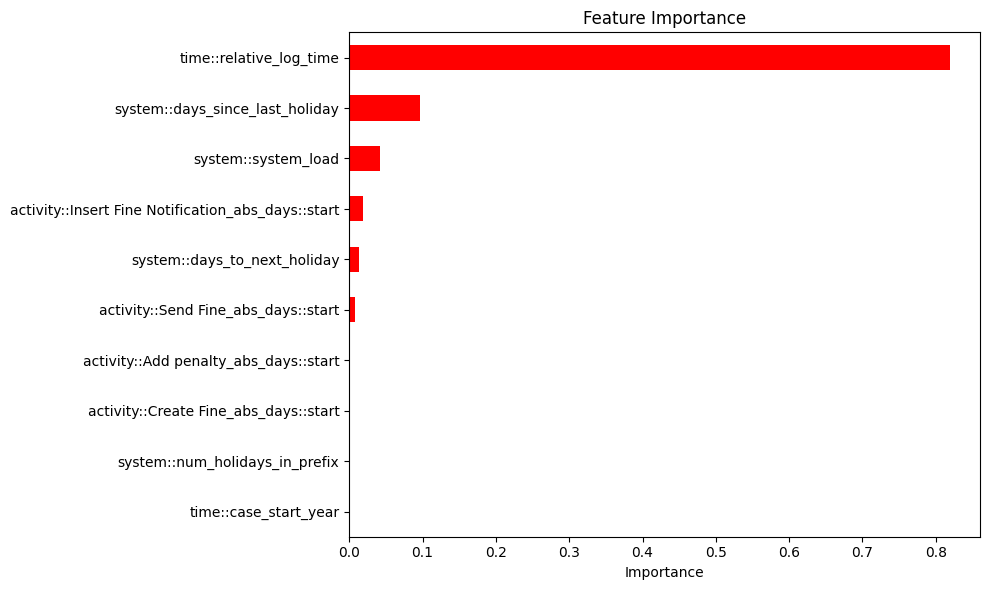

In [100]:
importances = pd.Series(reg.feature_importances_, index=X_train.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [101]:
# display(test_data)

## Evaluation

### Prediction Quality

In [102]:
plot_df = pd.DataFrame({
    'Actual (days)': y_test.values,
    'Predicted (days)': y_pred_numeric
})

reference_date = pd.Timestamp('2000-01-01', tz='Europe/Rome')
plot_df['Year'] = (reference_date + pd.to_timedelta(plot_df['Actual (days)'], unit='D')).dt.year.astype(str)

fig = px.scatter(
    plot_df,
    x='Actual (days)',
    y='Predicted (days)',
    color='Year',
    marginal_x='histogram',
    marginal_y='histogram',
    title='Actual vs Predicted Time to Credit Collection',
    opacity=0.6
)
fig.add_shape(
    type='line',
    x0=plot_df['Actual (days)'].min(),
    y0=plot_df['Actual (days)'].min(),
    x1=plot_df['Actual (days)'].max(),
    y1=plot_df['Actual (days)'].max(),
    line=dict(color='red', dash='dash', width=2)
)
fig.show()

In [103]:
plot_df = pd.DataFrame({
    'Actual (days)': y_test,
    'Predicted (days)': y_pred_numeric
})

fig = px.density_heatmap(
    plot_df,
    x='Actual (days)',
    y='Predicted (days)',
    title='Actual vs Predicted Time to Credit Collection',
    nbinsx=50,
    nbinsy=50
)
fig.add_shape(
    type='line',
    x0=plot_df['Actual (days)'].min(),
    y0=plot_df['Actual (days)'].min(),
    x1=plot_df['Actual (days)'].max(),
    y1=plot_df['Actual (days)'].max(),
    line=dict(color='red', dash='dash', width=2)
)
fig.show()

In [105]:
results_df = pd.DataFrame({
    'case_id': prefix_log_test['meta::case_id'].values,
    'prefix_length': prefix_log_test['meta::prefix_length'].values,
    'actual': y_test.values,
    'predicted': y_pred_numeric,
    'error': abs(y_test.values - y_pred_numeric)
})

mae_by_prefix = results_df.groupby('prefix_length').apply(
    lambda g: mean_absolute_error(g['actual'], g['predicted'])
).reset_index()
mae_by_prefix.columns = ['Prefix Length', 'MAE (days)']

fig = px.bar(
    mae_by_prefix,
    x='Prefix Length',
    y='MAE (days)',
    title='Average Prediction Error by Prefix Length'
)
fig.show()

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_7467/2514169406.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [106]:
print(f"Actual range: {results_df['actual'].min()} - {results_df['actual'].max()}")
print(f"Predicted range: {results_df['predicted'].min():.2f} - {results_df['predicted'].max():.2f}")
print(f"\nOutliers:")
print(results_df[results_df['error'] > 50][['case_id', 'prefix_length', 'actual', 'predicted', 'error']]
      .sort_values('error', ascending=False).to_string())

Actual range: 465 - 4862
Predicted range: 465.00 - 4862.00

Outliers:
      case_id  prefix_length  actual  predicted   error
3433   N38621              1    1820    1345.75  474.25
2028  N102144              5    3376    3661.67  285.67
4050   N48180              3    1820    1643.85  176.15
2097   N21276              5     465     600.50  135.50
1984  N100684              7    3376    3494.44  118.44
5141   N79952              5    3376    3485.20  109.20
7984  S160143              2    4862    4794.59   67.41


In [107]:
print(mae_by_prefix.to_string())

   Prefix Length  MAE (days)
0              1  237.125000
1              2   11.235000
2              3   16.013636
3              4    0.004526
4              5    1.247929
5              6    0.000000
6              7   30.456000
7              8    0.000000
8              9    1.410000


In [108]:
print(results_df.describe())

       prefix_length        actual     predicted         error
count   11808.000000  11808.000000  11808.000000  11808.000000
mean        4.050559   2631.571054   2631.572890      0.123416
std         0.324700   1402.964880   1403.009673      5.729634
min         1.000000    465.000000    465.000000      0.000000
25%         4.000000   1105.000000   1105.000000      0.000000
50%         4.000000   2615.000000   2615.000000      0.000000
75%         4.000000   3940.000000   3940.000000      0.000000
max         9.000000   4862.000000   4862.000000    474.250000


In [109]:
print(results_df[abs(results_df["predicted"] - results_df["actual"]) > 0])

      case_id  prefix_length  actual  predicted   error
365    A19195              4    3940    3945.28    5.28
491    A21884              4    3940    3945.28    5.28
1984  N100684              7    3376    3494.44  118.44
2028  N102144              5    3376    3661.67  285.67
2097   N21276              5     465     600.50  135.50
3433   N38621              1    1820    1345.75  474.25
4050   N48180              3    1820    1643.85  176.15
5141   N79952              5    3376    3485.20  109.20
5355   N85918              4    3376    3386.92   10.92
5426   N88252              4    3376    3397.84   21.84
6267  S114128              7    3376    3398.56   22.56
6283  S114719              9    3376    3381.64    5.64
6314  S115930              7    3376    3387.28   11.28
6681  S127899              4    4468    4475.88    7.88
7984  S160143              2    4862    4794.59   67.41


In [110]:
# Same case variant as N100684 (in training data)
print(prefix_log_train[prefix_log_train["meta::case_id"]=="S115992"])
print(prefix_log_train[prefix_log_train["meta::case_id"]=="A3350"])

      case::vehicleClass case::lifecycle:transition  case::article  case::points case::case:concept:name  case::expense case::notificationType case::lastSent  case::matricola  event::amount_min  ...  meta::prefix_length  time::avg_time_between_events time::max_time_between_events system::number_of_unique_resources system::num_holidays_in_prefix  system::days_to_next_holiday  system::days_since_last_holiday  system::system_load  target  system::duration_vs_period_avg
31728                  A                   complete          157.0           0.0                 S115992           22.0                      P              P              0.0               35.0  ...                    7                      47.571429                         145.0                                  1                             63                             1                               17                13397    3376                      153.820312

[1 rows x 71 columns]
     case::vehicleClass case::lifec

In [111]:
outlier_positions = results_df[results_df['error'] > 0].index
display(prefix_log_test.iloc[outlier_positions])

,case::vehicleClass,case::lifecycle:transition,case::article,case::points,case::case:concept:name,case::expense,case::notificationType,case::lastSent,case::matricola,event::amount_min,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target,system::duration_vs_period_avg
1897,A,complete,157.0,0.0,A19195,18.60,P,P,0.0,36.0,...,4,88.250000,277.0,1,35,17,61,14000,3940,163.675532
2513,A,complete,7.0,0.0,A21884,18.60,P,P,0.0,22.0,...,4,90.750000,283.0,1,35,17,61,14000,3940,174.312292
10381,A,complete,157.0,0.0,N100684,22.00,P,P,0.0,35.0,...,7,43.000000,140.0,1,64,1,17,13397,3376,84.439479
10593,A,complete,157.0,0.0,N102144,22.00,P,P,0.0,35.0,...,5,42.200000,134.0,1,64,1,17,13397,3376,-6.807018
10902,A,complete,157.0,0.0,N21276,6.46,P,N,0.0,31.3,...,5,57.400000,176.0,1,12,6,94,11170,465,143.241650
17486,A,complete,157.0,0.0,N38621,0.00,NaN,NaN,0.0,32.0,...,1,0.000000,0.0,1,33,1,17,12544,1820,-175.269939
20490,A,complete,157.0,0.0,N48180,15.16,P,N,0.0,33.6,...,3,123.000000,193.0,1,21,1,17,12544,1820,220.876056
25834,A,complete,7.0,0.0,N79952,11.00,P,P,0.0,21.0,...,5,36.000000,114.0,2,45,14,83,16324,3376,-21.229008
26926,A,complete,157.0,0.0,N85918,11.00,P,P,0.0,35.0,...,4,45.500000,118.0,1,41,14,83,16324,3376,-5.559701
27328,A,complete,157.0,0.0,N88252,11.00,P,P,0.0,35.0,...,4,49.250000,133.0,1,41,14,83,16324,3376,9.440299


In [112]:
# Compare outlier cases with correctly predicted cases that have same target
correct = results_df[(results_df['actual'] == 3376) & (results_df['error'] <= 5)]
display(prefix_log_test.iloc[correct.index[:20]][['meta::case_id', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'time::relative_log_time']])
display(prefix_log_test.iloc[outlier_positions][['meta::case_id', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'time::relative_log_time']])

,meta::case_id,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,time::relative_log_time
1,A10004,24,14,83,2821
16,A10050,24,14,83,2856
17,A10063,24,14,83,2820
19,A10068,24,14,83,2830
23,A10083,24,14,83,2830
29,A10115,24,14,83,2831
31,A10126,24,14,83,2833
32,A10127,24,14,83,2833
48,A10171,24,14,83,2830
53,A102,32,14,83,2619


,meta::case_id,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,time::relative_log_time
1897,A19195,35,17,61,3153
2513,A21884,35,17,61,3157
10381,N100684,64,1,17,2672
10593,N102144,64,1,17,2614
10902,N21276,12,6,94,299
17486,N38621,33,1,17,755
20490,N48180,21,1,17,1547
25834,N79952,45,14,83,2156
26926,N85918,41,14,83,2342
27328,N88252,41,14,83,2342


In [113]:
outlier_cases = event_log[
    (event_log["case:concept:name"] == "N100684") | 
    (event_log["case:concept:name"] == "N102144")
]
print(outlier_cases)

        amount org:resource dismissal                           concept:name vehicleClass  totalPaymentAmount lifecycle:transition            time:timestamp  article  points case:concept:name  expense notificationType lastSent  paymentAmount  matricola  relative_case_time  relative_log_time  time_since_prev
102193    35.0          550       NIL                            Create Fine            A                 0.0             complete 2006-06-29 02:00:00+02:00    157.0     0.0           N100684      NaN              NaN      NaN            NaN        NaN                   0               2371              0.0
102194     NaN          NaN       NaN                              Send Fine          NaN                 NaN             complete 2006-11-16 01:00:00+01:00      NaN     NaN           N100684     22.0              NaN      NaN            NaN        NaN                 140               2511            140.0
102195     NaN          NaN       NaN               Insert Fine Notificat

In [114]:
print(f"Actual range: {y_test.min()} - {y_test.max()}")
print(f"Predicted range: {y_pred_numeric.min():.1f} - {y_pred_numeric.max():.1f}")

Actual range: 465 - 4862
Predicted range: 465.0 - 4862.0


# Results

## Ablation Study

### High-level and Low-level Groups

In [115]:
case_cols = [col for col in X_train.columns if col.startswith('case::')]
event_cols = [col for col in X_train.columns if col.startswith('event::')]
activity_cols = [col for col in X_train.columns if col.startswith('activity::')]
time_cols = [col for col in X_train.columns if col.startswith('time::')]
system_cols = [col for col in X_train.columns if col.startswith('system::')]
meta_cols = [col for col in X_train.columns if col.startswith('meta::')]
print(system_cols)
print(activity_cols)

['system::number_of_unique_resources', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'system::system_load', 'system::duration_vs_period_avg']
['activity::num_Create Fine', 'activity::num_Send Fine', 'activity::num_Insert Fine Notification', 'activity::num_Add penalty', 'activity::num_Payment', 'activity::num_Insert Date Appeal to Prefecture', 'activity::num_Send Appeal to Prefecture', 'activity::num_Receive Result Appeal from Prefecture', 'activity::num_Notify Result Appeal to Offender', 'activity::num_Appeal to Judge', 'activity::Create Fine_abs_days::start', 'activity::Create Fine_days_since', 'activity::Send Fine_abs_days::start', 'activity::Send Fine_days_since', 'activity::Insert Fine Notification_abs_days::start', 'activity::Insert Fine Notification_days_since', 'activity::Add penalty_abs_days::start', 'activity::Add penalty_days_since', 'activity::Payment_abs_days::start', 'activity::Payment_days_since', 'activity::Insert Da

In [116]:
activity_start_cols = [col for col in activity_cols if not col.startswith('activity::num_')]
holiday_cols = [col for col in system_cols if 'holiday' in col]
resource_cols = [col for col in system_cols if 'resource' in col]
print(resource_cols)
print(activity_cols)

['system::number_of_unique_resources']
['activity::num_Create Fine', 'activity::num_Send Fine', 'activity::num_Insert Fine Notification', 'activity::num_Add penalty', 'activity::num_Payment', 'activity::num_Insert Date Appeal to Prefecture', 'activity::num_Send Appeal to Prefecture', 'activity::num_Receive Result Appeal from Prefecture', 'activity::num_Notify Result Appeal to Offender', 'activity::num_Appeal to Judge', 'activity::Create Fine_abs_days::start', 'activity::Create Fine_days_since', 'activity::Send Fine_abs_days::start', 'activity::Send Fine_days_since', 'activity::Insert Fine Notification_abs_days::start', 'activity::Insert Fine Notification_days_since', 'activity::Add penalty_abs_days::start', 'activity::Add penalty_days_since', 'activity::Payment_abs_days::start', 'activity::Payment_days_since', 'activity::Insert Date Appeal to Prefecture_abs_days::start', 'activity::Insert Date Appeal to Prefecture_days_since', 'activity::Send Appeal to Prefecture_abs_days::start', 'act

In [117]:
raw_sequence = [col for col in activity_cols if col.startswith('activity::num_')] + meta_cols
activity_start_times = [col for col in activity_cols if col.startswith('activity::')]
case_level = raw_sequence + case_cols
event_level = case_level + event_cols + activity_start_cols + time_cols
system_level = event_level + holiday_cols + resource_cols

In [118]:
print(raw_sequence)

['activity::num_Create Fine', 'activity::num_Send Fine', 'activity::num_Insert Fine Notification', 'activity::num_Add penalty', 'activity::num_Payment', 'activity::num_Insert Date Appeal to Prefecture', 'activity::num_Send Appeal to Prefecture', 'activity::num_Receive Result Appeal from Prefecture', 'activity::num_Notify Result Appeal to Offender', 'activity::num_Appeal to Judge', 'meta::prefix_length']


In [119]:
print(event_level)
print(case_level)
print(system_level)

['activity::num_Create Fine', 'activity::num_Send Fine', 'activity::num_Insert Fine Notification', 'activity::num_Add penalty', 'activity::num_Payment', 'activity::num_Insert Date Appeal to Prefecture', 'activity::num_Send Appeal to Prefecture', 'activity::num_Receive Result Appeal from Prefecture', 'activity::num_Notify Result Appeal to Offender', 'activity::num_Appeal to Judge', 'meta::prefix_length', 'case::vehicleClass', 'case::lifecycle:transition', 'case::article', 'case::points', 'case::case:concept:name', 'case::expense', 'case::notificationType', 'case::lastSent', 'case::matricola', 'event::amount_min', 'event::amount_max', 'event::amount_last', 'event::org:resource_last', 'event::dismissal_last', 'event::concept:name_last', 'event::totalPaymentAmount_min', 'event::totalPaymentAmount_max', 'event::totalPaymentAmount_last', 'event::paymentAmount_min', 'event::paymentAmount_max', 'event::paymentAmount_last', 'activity::Create Fine_abs_days::start', 'activity::Create Fine_days_si

In [120]:
print(y_train_numeric)

0        3376
2        3376
3        3376
4        3376
5        3376
         ... 
58882    1470
58883    1470
58885    1470
58887    1470
58888    1470
Name: target, Length: 47081, dtype: int64


In [121]:
high_level_variants, granular_variants = get_ablation_variants(X_train)

In [122]:
road_fines_results = run_ablation(X_train, X_test, y_train_numeric, y_test_numeric, granular_variants)

In [123]:
display(road_fines_results)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,1244.865,1401.384,0.002,11
1,+ Case attributes,40.244,138.052,0.990,20
2,+ Event aggregations,38.841,135.206,0.991,32
3,+ Activity start times,24.679,102.336,0.995,52
4,+ Temporal features,25.117,101.334,0.995,60
5,+ System features,0.132,6.049,1.000,66
6,Full pipeline,0.132,6.049,1.000,66


In [124]:
road_fines_results_high = run_ablation(X_train, X_test, y_train_numeric, y_test_numeric, high_level_variants)
display(road_fines_results_high)


,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,1244.865,1401.384,0.002,11
1,+ Case-level features,40.244,138.052,0.990,20
2,+ Event-level features,25.117,101.334,0.995,60
3,+ System-level features,0.132,6.049,1.000,66
4,Full pipeline,0.132,6.049,1.000,66


In [125]:
display(road_fines_results_high)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,1244.865,1401.384,0.002,11
1,+ Case-level features,40.244,138.052,0.990,20
2,+ Event-level features,25.117,101.334,0.995,60
3,+ System-level features,0.132,6.049,1.000,66
4,Full pipeline,0.132,6.049,1.000,66


In [126]:
system_variant_cols = raw_sequence + case_cols + event_cols + activity_start_cols + time_cols + system_cols
available_system = [c for c in system_variant_cols if c in X_train.columns]
available_full = list(X_train.columns)

print("System variant:", len(available_system))
print("Full pipeline:", len(available_full))
print("In full but not system:", set(available_full) - set(available_system))
print("In system but not full:", set(available_system) - set(available_full))
display(X_train.columns)
display(available_system)

System variant: 66
Full pipeline: 66
In full but not system: set()
In system but not full: set()


Index(['case::vehicleClass', 'case::lifecycle:transition', 'case::article',
       'case::points', 'case::case:concept:name', 'case::expense',
       'case::notificationType', 'case::lastSent', 'case::matricola',
       'event::amount_min', 'event::amount_max', 'event::amount_last',
       'event::org:resource_last', 'event::dismissal_last',
       'event::concept:name_last', 'event::totalPaymentAmount_min',
       'event::totalPaymentAmount_max', 'event::totalPaymentAmount_last',
       'event::paymentAmount_min', 'event::paymentAmount_max',
       'event::paymentAmount_last', 'time::relative_log_time',
       'time::relative_case_time', 'time::time_since_prev',
       'activity::num_Create Fine', 'activity::num_Send Fine',
       'activity::num_Insert Fine Notification', 'activity::num_Add penalty',
       'activity::num_Payment',
       'activity::num_Insert Date Appeal to Prefecture',
       'activity::num_Send Appeal to Prefecture',
       'activity::num_Receive Result Appeal from

['activity::num_Create Fine',
 'activity::num_Send Fine',
 'activity::num_Insert Fine Notification',
 'activity::num_Add penalty',
 'activity::num_Payment',
 'activity::num_Insert Date Appeal to Prefecture',
 'activity::num_Send Appeal to Prefecture',
 'activity::num_Receive Result Appeal from Prefecture',
 'activity::num_Notify Result Appeal to Offender',
 'activity::num_Appeal to Judge',
 'meta::prefix_length',
 'case::vehicleClass',
 'case::lifecycle:transition',
 'case::article',
 'case::points',
 'case::case:concept:name',
 'case::expense',
 'case::notificationType',
 'case::lastSent',
 'case::matricola',
 'event::amount_min',
 'event::amount_max',
 'event::amount_last',
 'event::org:resource_last',
 'event::dismissal_last',
 'event::concept:name_last',
 'event::totalPaymentAmount_min',
 'event::totalPaymentAmount_max',
 'event::totalPaymentAmount_last',
 'event::paymentAmount_min',
 'event::paymentAmount_max',
 'event::paymentAmount_last',
 'activity::Create Fine_abs_days::start'

### Single Feature Ablation Study

In [127]:
variants = get_targeted_variants(X_train, "activity::Create Fine_abs_days::start")

In [128]:
results, importances = run_ablation_with_importance(X_train, X_test, y_train_numeric, y_test_numeric, variants)
display(results)
for name, importance in importances.items():
    print(f"\n{name}")
    display(importance)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.132,6.049,1.0,66
1,Without relative_log_time,0.183,13.071,1.0,65
2,Without activity::Create Fine_abs_days::start,0.140,6.664,1.0,65
3,Without both,0.172,12.977,1.0,64



Full pipeline


time::relative_log_time                               0.819293
system::days_since_last_holiday                       0.097894
system::system_load                                   0.042168
activity::Insert Fine Notification_abs_days::start    0.018271
system::days_to_next_holiday                          0.012295
activity::Send Fine_abs_days::start                   0.008550
activity::Add penalty_abs_days::start                 0.001045
activity::Create Fine_abs_days::start                 0.000385
system::num_holidays_in_prefix                        0.000074
time::case_start_year                                 0.000018
dtype: float64


Without relative_log_time


activity::Send Fine_abs_days::start                   0.795034
system::days_since_last_holiday                       0.099318
system::system_load                                   0.078017
system::days_to_next_holiday                          0.017948
activity::Insert Fine Notification_abs_days::start    0.008280
activity::Create Fine_abs_days::start                 0.001097
system::num_holidays_in_prefix                        0.000109
activity::Add penalty_abs_days::start                 0.000083
time::case_start_year                                 0.000044
time::avg_time_between_events                         0.000013
dtype: float64


Without activity::Create Fine_abs_days::start


time::relative_log_time                               0.819521
system::days_since_last_holiday                       0.097562
system::system_load                                   0.041620
activity::Insert Fine Notification_abs_days::start    0.018503
system::days_to_next_holiday                          0.013160
activity::Send Fine_abs_days::start                   0.009160
activity::Add penalty_abs_days::start                 0.000412
time::case_start_year                                 0.000049
system::num_holidays_in_prefix                        0.000005
event::amount_min                                     0.000001
dtype: float64


Without both


activity::Send Fine_abs_days::start                   0.786970
system::days_since_last_holiday                       0.100198
system::system_load                                   0.078952
system::days_to_next_holiday                          0.017167
activity::Insert Fine Notification_abs_days::start    0.016168
activity::Add penalty_abs_days::start                 0.000315
system::num_holidays_in_prefix                        0.000151
activity::num_Insert Fine Notification                0.000013
time::relative_case_time                              0.000011
time::avg_time_between_events                         0.000010
dtype: float64

In [129]:
case_cols = [col for col in X_train.columns if col.startswith('case::')]
variants = {'Full pipeline': list(X_train.columns)}
for col in case_cols:
    variants[f'Without {col}'] = [c for c in X_train.columns if c != col]

results_case, importances_case = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results_case)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.132,6.049,1.0,66
1,Without case::vehicleClass,0.123,5.800,1.0,65
2,Without case::lifecycle:transition,0.131,6.134,1.0,65
3,Without case::article,0.116,5.673,1.0,65
4,Without case::points,0.130,6.124,1.0,65
5,Without case::case:concept:name,0.118,5.726,1.0,65
6,Without case::expense,0.117,5.672,1.0,65
7,Without case::notificationType,0.131,6.329,1.0,65
8,Without case::lastSent,0.117,5.672,1.0,65
9,Without case::matricola,0.131,6.134,1.0,65


### Single Group Analysis

In [130]:
run_group_only_analysis(X_train, X_test, y_train, y_test, 'case')
run_group_only_analysis(X_train, X_test, y_train, y_test, 'system')
run_group_only_analysis(X_train, X_test, y_train, y_test, 'event')

case columns: ['case::vehicleClass', 'case::lifecycle:transition', 'case::article', 'case::points', 'case::case:concept:name', 'case::expense', 'case::notificationType', 'case::lastSent', 'case::matricola']
case::lastSent                0.742133
case::case:concept:name       0.144989
case::expense                 0.109640
case::points                  0.001676
case::article                 0.001353
case::vehicleClass            0.000178
case::notificationType        0.000030
case::lifecycle:transition    0.000000
case::matricola               0.000000
dtype: float64
MAE case only: 40.89246443089431
system columns: ['system::number_of_unique_resources', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'system::system_load', 'system::duration_vs_period_avg']
system::days_since_last_holiday       0.796185
system::days_to_next_holiday          0.179428
system::system_load                   0.024378
system::num_holidays_in_prefix        0.

(RandomForestRegressor(random_state=42),
 event::amount_min                 8.673934e-01
 event::amount_max                 6.178367e-02
 event::amount_last                6.330868e-02
 event::org:resource_last          6.757672e-03
 event::dismissal_last             2.872666e-07
 event::concept:name_last          2.997876e-04
 event::totalPaymentAmount_min     0.000000e+00
 event::totalPaymentAmount_max     8.711784e-05
 event::totalPaymentAmount_last    9.147777e-05
 event::paymentAmount_min          9.736853e-05
 event::paymentAmount_max          9.690756e-05
 event::paymentAmount_last         8.358111e-05
 dtype: float64)

## Interpretation

### Target Analysis

In [131]:
import plotly.express as px
A_pending_events = event_log[event_log["concept:name"] == "Send for Credit Collection"]
fig = px.histogram(A_pending_events, x="relative_case_time")
fig.add_vline(x=372, line_width=3, line_dash="dash", line_color="red")
fig.show()

In [132]:
print(f"Cases: {event_log['case:concept:name'].nunique()}")
print(f"Events: {len(event_log)}")
print(f"Activities: {event_log['concept:name'].nunique()}")
print(f"Time span: {event_log['time:timestamp'].min()} to {event_log['time:timestamp'].max()}")
print(event_log.groupby('case:concept:name').size().describe())
print(event_log['concept:name'].unique())

Cases: 150370
Events: 561470
Activities: 11
Time span: 2000-01-01 01:00:00+01:00 to 2013-06-18 02:00:00+02:00
count    150370.000000
mean          3.733923
std           1.641017
min           2.000000
25%           2.000000
50%           5.000000
75%           5.000000
max          20.000000
dtype: float64
['Create Fine' 'Send Fine' 'Insert Fine Notification' 'Add penalty'
 'Send for Credit Collection' 'Payment' 'Insert Date Appeal to Prefecture'
 'Send Appeal to Prefecture' 'Receive Result Appeal from Prefecture'
 'Notify Result Appeal to Offender' 'Appeal to Judge']


In [133]:
scc_events = event_log[event_log['concept:name'] == 'Send for Credit Collection']
batch_counts = scc_events.groupby(scc_events['time:timestamp'].dt.date).size().reset_index()
batch_counts.columns = ['Date', 'Cases']
print(batch_counts.to_string())

          Date  Cases
0   2001-04-10    247
1   2002-04-10   9136
2   2003-01-10   6270
3   2004-01-10   4172
4   2004-12-25   4155
5   2006-02-28   5011
6   2007-02-28   4451
7   2009-03-30   8851
8   2010-10-15   5015
9   2012-03-26   6924
10  2013-04-24   4781


In [134]:
print(case_log.index[:5])
print(case_log.head())

Index(['A1', 'A100', 'A10000', 'A10001', 'A10004'], dtype='object', name='case:concept:name')
                                 start_time                  end_time  no_of_events duration        Create_Fine::start          Send_Fine::start Insert_Fine_Notification::start        Add_penalty::start Send_for_Credit_Collection::start            Payment::start Insert_Date_Appeal_to_Prefecture::start Send_Appeal_to_Prefecture::start Receive_Result_Appeal_from_Prefecture::start Notify_Result_Appeal_to_Offender::start Appeal_to_Judge::start
case:concept:name                                                                                                                                                                                                                                                                                                                                                                                                                                          
A1                

### Outlier Analysis

In [137]:
outlier_cases = ['N38621', 'N102144', 'N48180']
for case in outlier_cases:
    print(f"\n{case}")
    subset = event_log[event_log['case:concept:name'].str.contains(case)]
    print(subset[['concept:name', 'time:timestamp', 'relative_case_time', 'relative_log_time']].to_string())


N38621
                      concept:name            time:timestamp  relative_case_time  relative_log_time
152719                 Create Fine 2002-01-25 01:00:00+01:00                   0                755
152720                   Send Fine 2003-05-20 02:00:00+02:00                 480               1235
152721    Insert Fine Notification 2003-06-21 02:00:00+02:00                 512               1267
152722                 Add penalty 2003-08-20 02:00:00+02:00                 572               1327
152723  Send for Credit Collection 2004-12-25 01:00:00+01:00                1065               1820

N102144
                                 concept:name            time:timestamp  relative_case_time  relative_log_time
104661                            Create Fine 2006-07-31 02:00:00+02:00                   0               2403
104662                              Send Fine 2006-12-12 01:00:00+01:00                 134               2537
104663               Insert Fine Notification 2006

In [138]:
# Check if article distribution differs across batch years
road_fines_cases = event_log[event_log['concept:name'] == 'Send for Credit Collection'][['case:concept:name', 'time:timestamp']].copy()
road_fines_cases['batch_year'] = road_fines_cases['time:timestamp'].dt.year

case_attributes = event_log.groupby('case:concept:name').first()[['article', 'vehicleClass', 'points']]
merged = road_fines_cases.merge(case_attributes, left_on='case:concept:name', right_index=True)

print(merged.groupby('batch_year')['article'].value_counts(normalize=True).unstack().fillna(0).round(3))
print(merged.groupby('batch_year')['vehicleClass'].value_counts(normalize=True).unstack().fillna(0).round(3))

article     7.0    15.0   20.0   21.0   23.0   40.0   41.0   43.0   61.0   68.0   ...  181.0  188.0  189.0  190.0  191.0  192.0  193.0  213.0  214.0  401.0
batch_year                                                                        ...                                                                      
2001        0.215    0.0  0.000    0.0  0.000    0.0  0.008  0.000    0.0    0.0  ...  0.016  0.000    0.0  0.004  0.000    0.0  0.016  0.000    0.0  0.000
2002        0.244    0.0  0.000    0.0  0.000    0.0  0.003  0.009    0.0    0.0  ...  0.004  0.000    0.0  0.000  0.002    0.0  0.001  0.000    0.0  0.000
2003        0.280    0.0  0.001    0.0  0.001    0.0  0.007  0.016    0.0    0.0  ...  0.010  0.000    0.0  0.000  0.000    0.0  0.001  0.000    0.0  0.000
2004        0.239    0.0  0.001    0.0  0.000    0.0  0.007  0.003    0.0    0.0  ...  0.003  0.001    0.0  0.000  0.001    0.0  0.003  0.000    0.0  0.000
2006        0.215    0.0  0.001    0.0  0.001    0.0  0.002  0.0

In [139]:
results, importances = run_single_group_removal(X_train, X_test, y_train, y_test, 'case', exclude=['case::case:concept:name'])
display(results)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.132,6.049,1.0,66
1,Without case::vehicleClass,0.123,5.800,1.0,65
2,Without case::lifecycle:transition,0.131,6.134,1.0,65
3,Without case::article,0.116,5.673,1.0,65
4,Without case::points,0.130,6.124,1.0,65
5,Without case::expense,0.117,5.672,1.0,65
6,Without case::notificationType,0.131,6.329,1.0,65
7,Without case::lastSent,0.117,5.672,1.0,65
8,Without case::matricola,0.131,6.134,1.0,65


In [140]:
# Check what label encoding does to case:concept:name in road fines
case_name_encoded = X_train['case::case:concept:name'].values
print(case_name_encoded)

# Check correlation between encoded case ID and target
correlation = pd.Series(X_train['case::case:concept:name'].values).corr(pd.Series(y_train.values))
print("Correlation between encoded case:concept:name and target:", correlation)

[    0     2     3 ... 58885 58887 58888]
Correlation between encoded case:concept:name and target: -0.12041889320384448
